## Crypto Portfolio Optimization 
### Exploratory Data Analysis

In [2]:
import yfinance as yf
import pandas as pd

In [ ]:
from db import load_df

df = load_df('raw_prices')
df['Date'] = pd.to_datetime(df['Date'])
df.head(3)
df

In [4]:
sorted_df = df.sort_values(by='Close', ascending=False)
sorted_df


,Date,Open,High,Low,Close,Adj Close,Volume($),Symbol,Daily Return
433,2021-11-08,63344.066406,67673.742188,63344.066406,67566.828125,67566.828125,41125608330,BTC,0.066952
434,2021-11-09,67549.734375,68530.335938,66382.062500,66971.828125,66971.828125,42357991721,BTC,-0.008806
414,2021-10-20,64284.585938,66930.390625,63610.675781,65992.835938,65992.835938,40788955582,BTC,0.026934
439,2021-11-14,64455.371094,65495.179688,63647.808594,65466.839844,65466.839844,25122092191,BTC,0.015470
435,2021-11-10,66953.335938,68789.625000,63208.113281,64995.230469,64995.230469,48730828378,BTC,-0.029514
...,...,...,...,...,...,...,...,...,...
10183,2020-10-31,0.002598,0.002603,0.002556,0.002576,0.002576,56189318,DOGE,-0.008468
10145,2020-09-23,0.002648,0.002651,0.002540,0.002560,0.002560,79707709,DOGE,-0.036145
10187,2020-11-04,0.002528,0.002558,0.002497,0.002533,0.002533,52552651,DOGE,0.001978
10186,2020-11-03,0.002517,0.002530,0.002452,0.002528,0.002528,62871653,DOGE,0.004370


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17731 entries, 0 to 17730
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          17731 non-null  datetime64[ns]
 1   Open          17731 non-null  float64       
 2   High          17731 non-null  float64       
 3   Low           17731 non-null  float64       
 4   Close         17731 non-null  float64       
 5   Adj Close     17731 non-null  float64       
 6   Volume($)     17731 non-null  int64         
 7   Symbol        17731 non-null  object        
 8   Daily Return  17717 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 1.2+ MB


In [6]:
Crypto_count = df['Symbol'].value_counts()
Crypto_count

Symbol
BTC      1268
ETH      1268
USDT     1268
BNB      1268
SOL      1268
XRP      1268
ADA      1268
DOGE     1268
TRX      1268
LINK     1268
DOT      1268
MATIC    1268
TON      1268
AVAX     1247
Name: count, dtype: int64

### Crypto Market History Data - EDA 

In [7]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume($),Daily Return
count,17731,17731.000000,17731.000000,17731.000000,17731.000000,17731.000000,1.773100e+04,17717.000000
mean,2022-05-28 05:43:22.289775360,2557.973234,2617.182488,2494.587639,2560.165638,2560.165638,8.565989e+09,0.002865
min,2020-09-01 00:00:00,0.002517,0.002530,0.002452,0.002517,0.002517,0.000000e+00,-0.423340
25%,2021-07-16 00:00:00,0.600575,0.620254,0.573701,0.601234,0.601234,3.011982e+08,-0.020516
50%,2022-05-28 00:00:00,4.344504,4.522180,4.193647,4.343831,4.343831,9.532551e+08,0.000058
75%,2023-04-10 00:00:00,41.874537,44.003510,39.834667,41.929300,41.929300,4.226488e+09,0.021600
max,2024-02-20 00:00:00,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11,3.555466
std,NaN,9270.938199,9487.542959,9035.261370,9276.859493,9276.859493,1.974031e+10,0.063092


In [8]:
zero_counts = (df == 0).sum()

zero_counts

Date             0
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume($)       83
Symbol           0
Daily Return     4
dtype: int64

In [9]:
# Filter the dataset to get rows where the Volume is 0
rows_with_zero_volume = df[df['Volume($)'] == 0]

rows_with_zero_volume


,Date,Open,High,Low,Close,Adj Close,Volume($),Symbol,Daily Return
16681,2021-04-07,20.524376,20.524376,10.762482,15.106609,15.106609,0,TON,-0.260549
16682,2021-04-08,15.097154,20.588436,15.097154,20.544950,20.544950,0,TON,0.359997
16683,2021-04-09,20.705929,22.148657,19.256044,21.431704,21.431704,0,TON,0.043162
16684,2021-04-10,21.297989,21.297989,19.381647,19.950258,19.950258,0,TON,-0.069124
16685,2021-04-11,19.959171,22.064671,16.544319,19.461653,19.461653,0,TON,-0.024491
...,...,...,...,...,...,...,...,...,...
16761,2021-06-26,3.880729,3.973782,3.468217,3.805105,3.805105,0,TON,-0.035987
16762,2021-06-27,3.805123,3.889615,3.605698,3.880750,3.880750,0,TON,0.019880
16763,2021-06-28,3.885186,4.361260,3.728421,4.296169,4.296169,0,TON,0.107046
16764,2021-06-29,4.327189,4.938786,4.049628,4.666017,4.666017,0,TON,0.086088


In [10]:
Crypto_count = rows_with_zero_volume['Symbol'].value_counts()
Crypto_count

Symbol
TON    83
Name: count, dtype: int64

#### Correlation Analysis

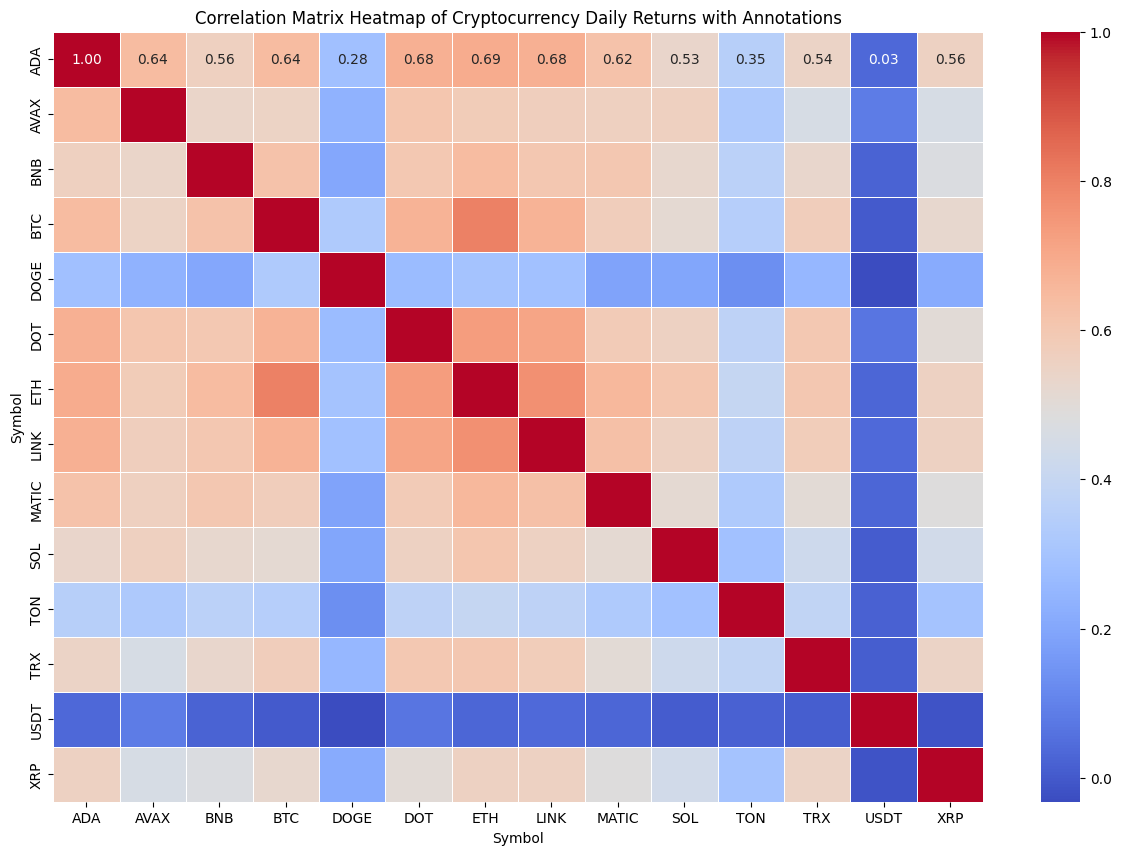

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the data to have symbols as columns and dates as rows for the daily returns
pivot_returns = df.pivot_table(values='Daily Return', index='Date', columns='Symbol', aggfunc='first')

correlation_matrix = df.pivot_table(values='Daily Return', index='Date', columns='Symbol', aggfunc='first').corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap of Cryptocurrency Daily Returns with Annotations')
plt.show()

In [12]:
Crypto_count = df['Symbol'].value_counts()
Crypto_count

Symbol
BTC      1268
ETH      1268
USDT     1268
BNB      1268
SOL      1268
XRP      1268
ADA      1268
DOGE     1268
TRX      1268
LINK     1268
DOT      1268
MATIC    1268
TON      1268
AVAX     1247
Name: count, dtype: int64

#### Trend Analysis

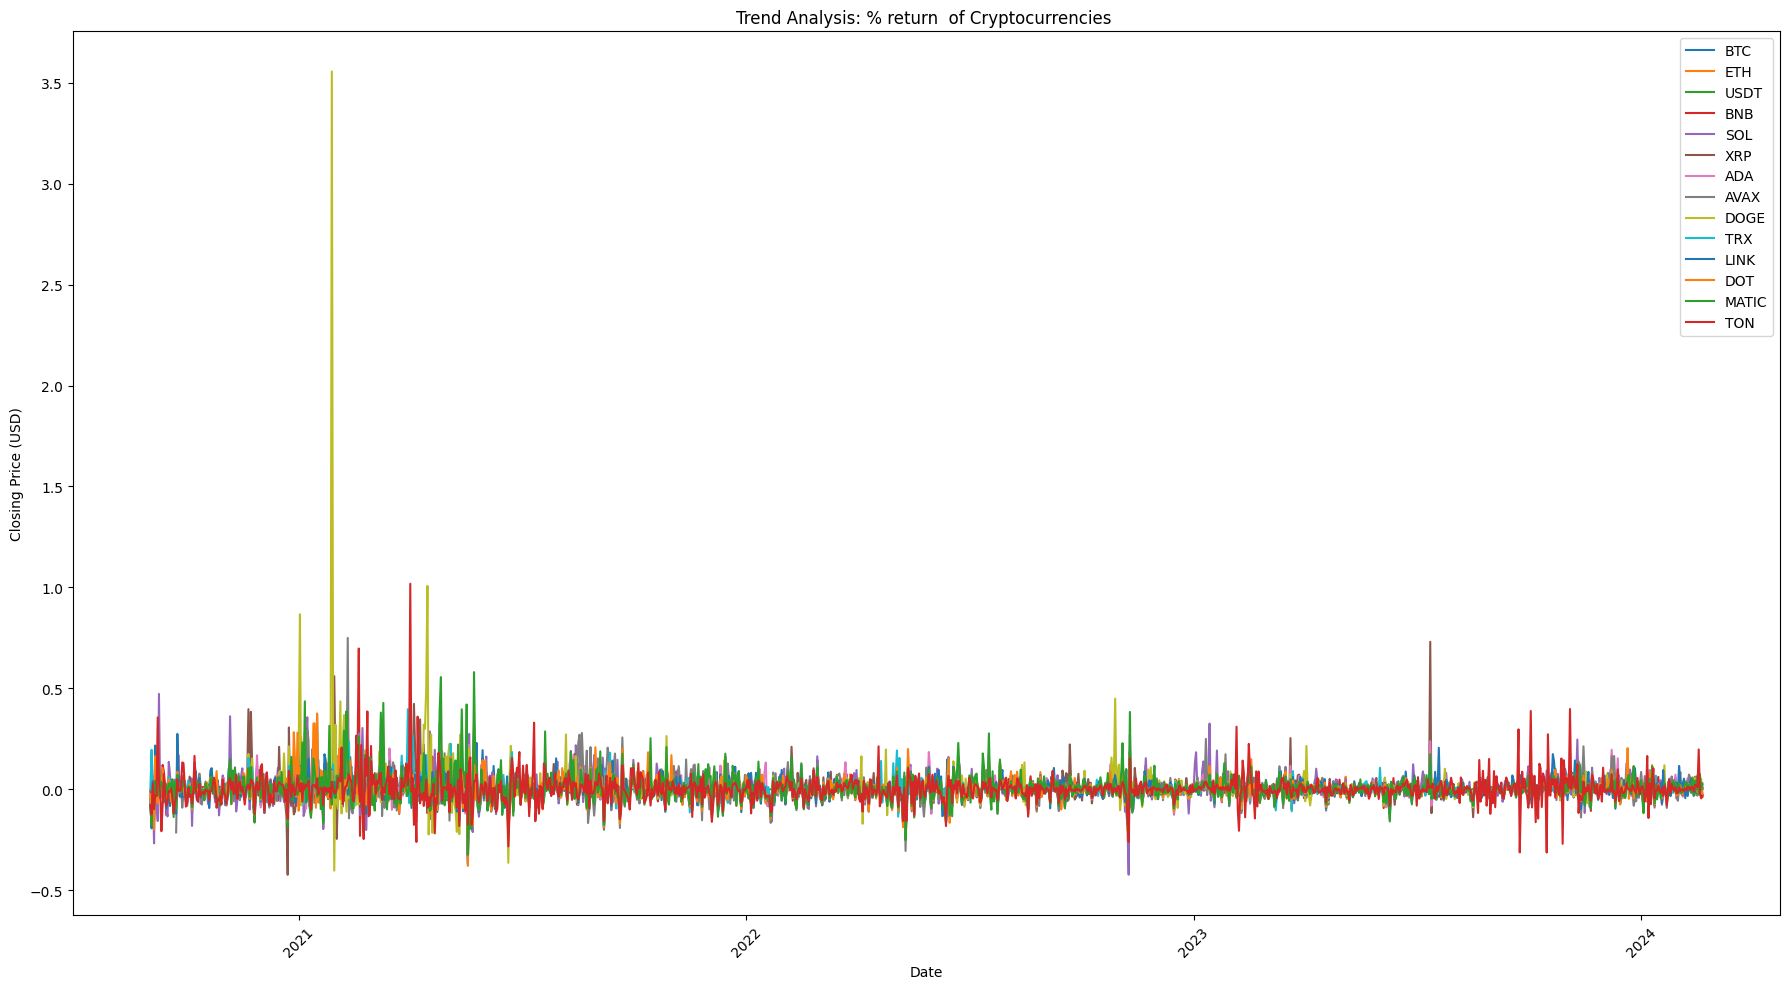

In [14]:
import matplotlib.dates as mdates
excluded_cryptos = ['WBTC']


crypto_data_excluded = df[~df['Symbol'].isin(excluded_cryptos)]

crypto_data_excluded['Date'] = pd.to_datetime(crypto_data_excluded['Date'])

plt.figure(figsize=(18, 10))

for symbol in crypto_data_excluded['Symbol'].unique():
    subset = crypto_data_excluded[crypto_data_excluded['Symbol'] == symbol]
    plt.plot(subset['Date'], subset['Daily Return'], label=symbol)

# Set the locator for the x-axis to pick dates at regular intervals
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)

plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)

plt.title('Trend Analysis: % return  of Cryptocurrencies ')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


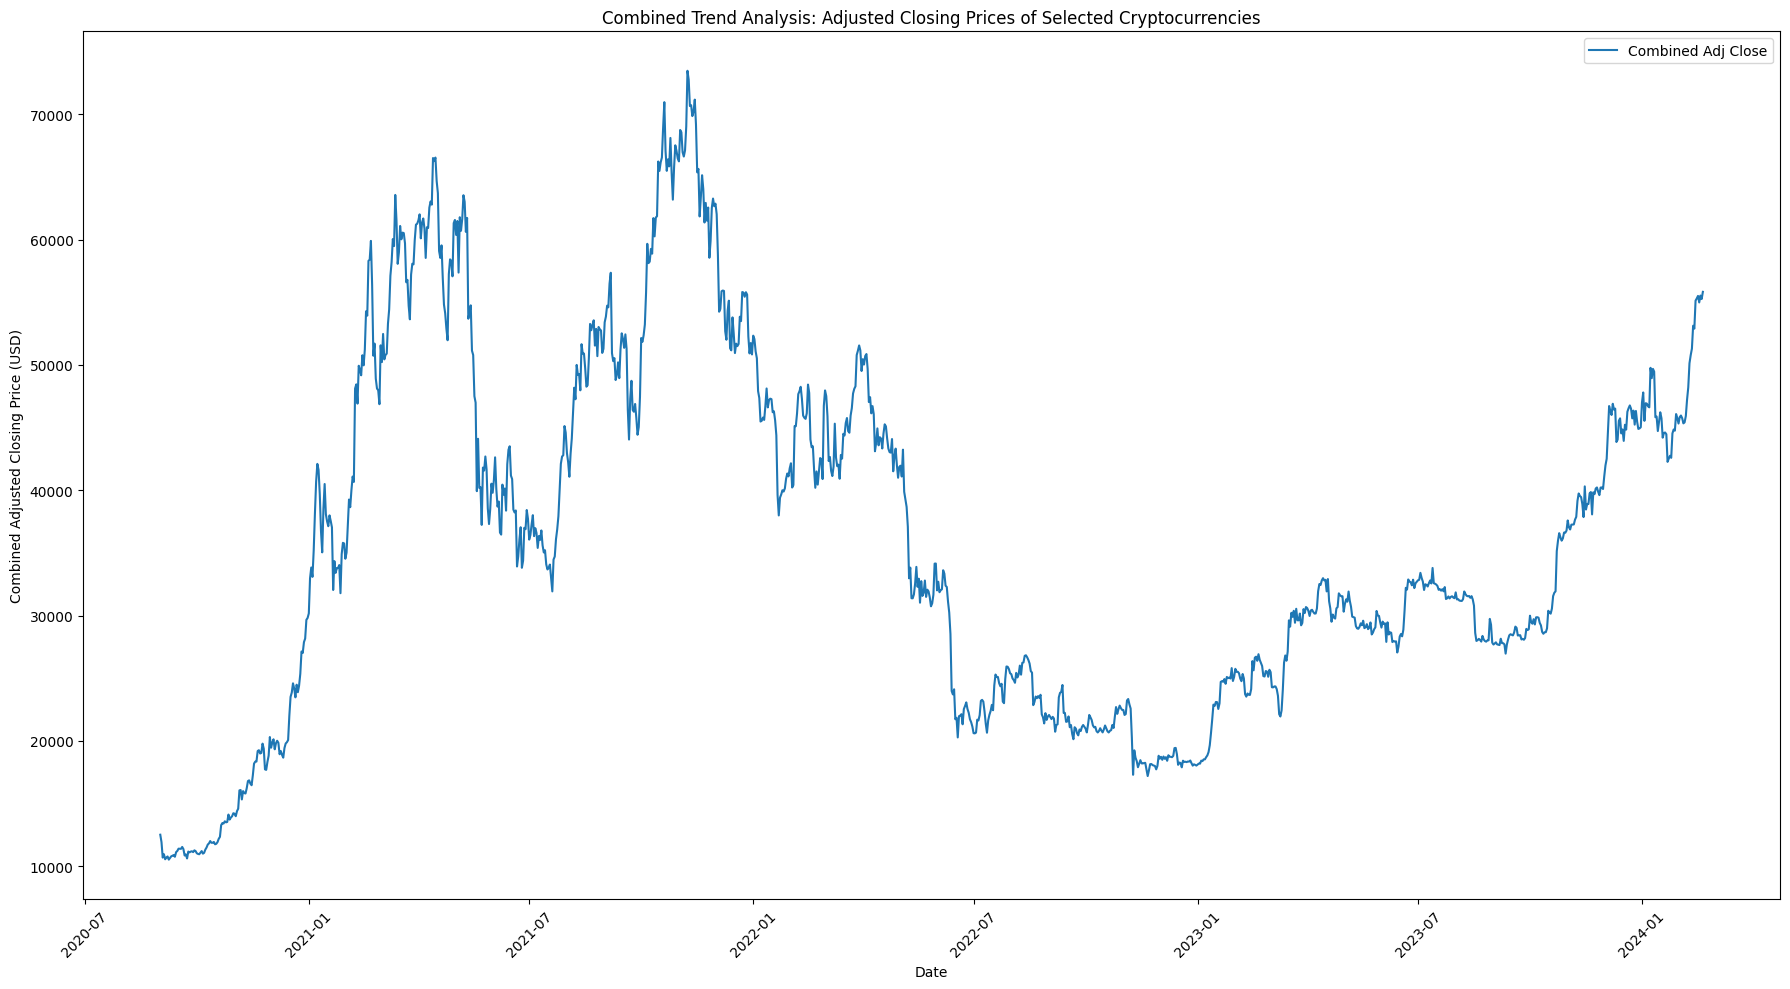

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

selected_cryptos = ['BTC', 'ETH', 'USDT', 'BNB', 'SOL', 'XRP', 'ADA', 'AVAX', 'DOGE',
       'TRX', 'LINK', 'DOT', 'MATIC', 'TON']

crypto_data_selected = df[df['Symbol'].isin(selected_cryptos)]

crypto_data_selected['Date'] = pd.to_datetime(crypto_data_selected['Date'])

# Grouping the data by 'Date' and summing the 'Adj Close' values for each date
combined_adj_close = crypto_data_selected.groupby('Date')['Adj Close'].sum().reset_index()

plt.figure(figsize=(18, 10))
plt.plot(combined_adj_close['Date'], combined_adj_close['Adj Close'], label='Combined Adj Close')

plt.title('Combined Trend Analysis: Adjusted Closing Prices of Selected Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Combined Adjusted Closing Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


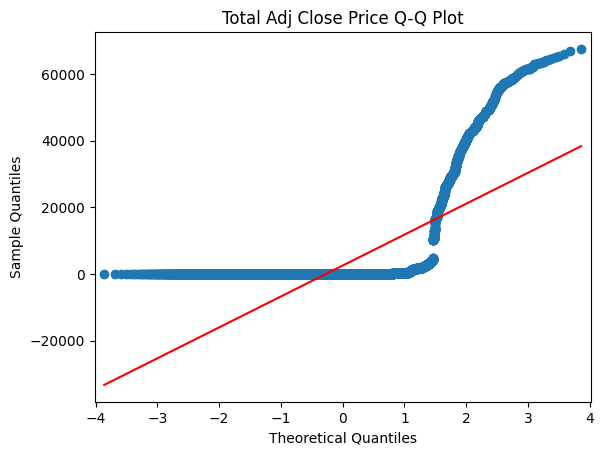

In [27]:
from statsmodels.graphics.gofplots import qqplot

btc_adj_close = df['Adj Close']

# Generate the Q-Q plot
qqplot(btc_adj_close, line='s')
plt.title('Total Adj Close Price Q-Q Plot')
plt.show()

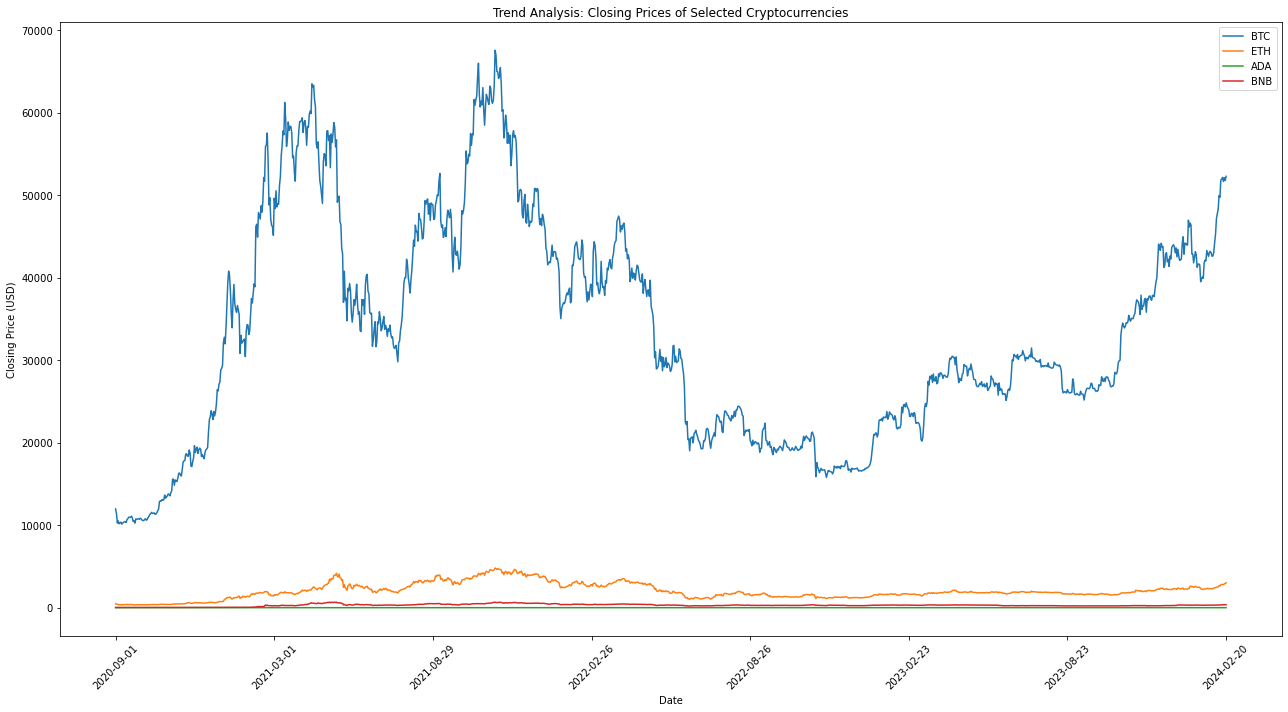

In [27]:
selected_cryptos = ['BTC', 'ETH', 'ADA', 'BNB']

crypto_data_selected = df[df['Symbol'].isin(selected_cryptos)]

# Plotting the time-series graph for the selected cryptocurrencies' closing prices
plt.figure(figsize=(18, 10))

for symbol in selected_cryptos:
    subset = crypto_data_selected[crypto_data_selected['Symbol'] == symbol]
    plt.plot(subset['Date'], subset['Close'], label=symbol)
    
# Simplify the date ticks to display only 8 dates
plt.xticks(pd.date_range(start=df['Date'].min(), end=df['Date'].max(), periods=8))

plt.title('Trend Analysis: Closing Prices of Selected Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Ethan Vaz Falcao\AppData\Local\Temp\ipykernel_19348\147885312.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crypto_data_excluded['Date'] = pd.to_datetime(crypto_data_excluded['Date'])


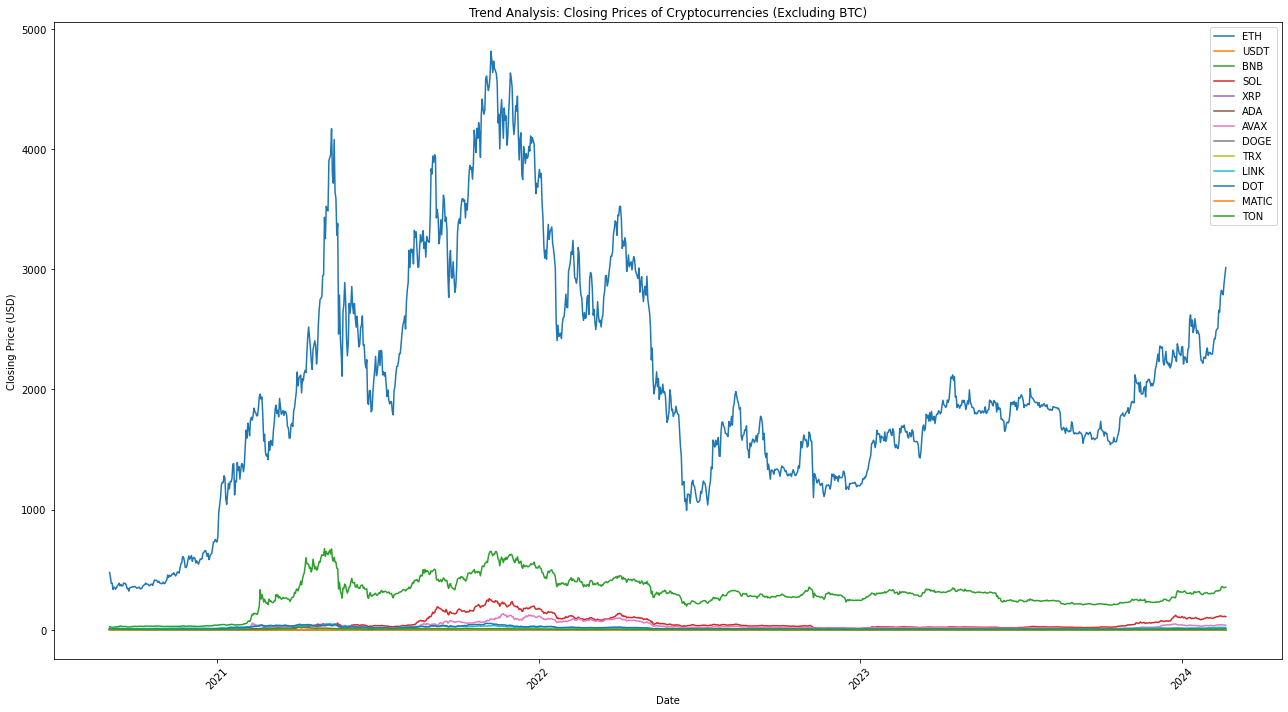

In [28]:
excluded_cryptos = ['BTC', 'WBTC']

crypto_data_excluded = df[~df['Symbol'].isin(excluded_cryptos)]

crypto_data_excluded['Date'] = pd.to_datetime(crypto_data_excluded['Date'])

plt.figure(figsize=(18, 10))

for symbol in crypto_data_excluded['Symbol'].unique():
    subset = crypto_data_excluded[crypto_data_excluded['Symbol'] == symbol]
    plt.plot(subset['Date'], subset['Close'], label=symbol)

# Set the locator for the x-axis to pick dates at regular intervals
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)

plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)

plt.title('Trend Analysis: Closing Prices of Cryptocurrencies (Excluding BTC)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\Ethan Vaz Falcao\AppData\Local\Temp\ipykernel_19348\3222229411.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crypto_data_excluded['Date'] = pd.to_datetime(crypto_data_excluded['Date'])


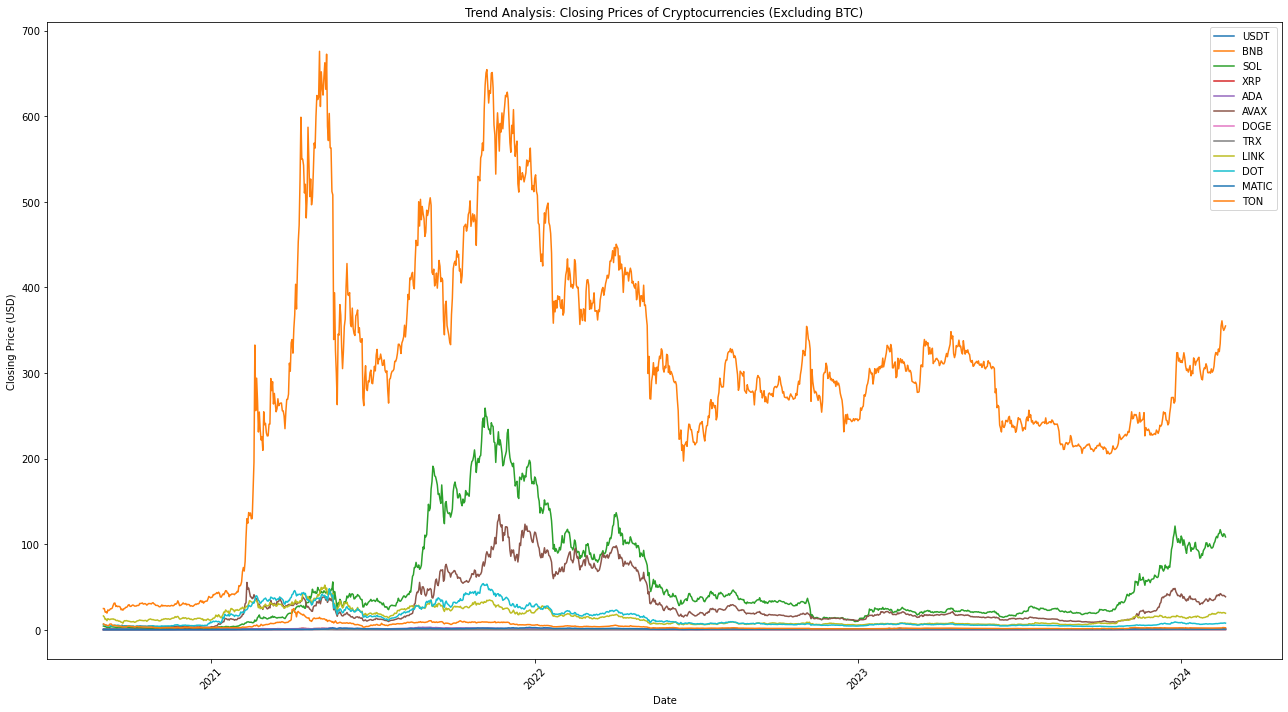

In [29]:

excluded_cryptos = ['BTC', 'ETH']

# Filter the dataset to exclude the selected cryptocurrencies
crypto_data_excluded = df[~df['Symbol'].isin(excluded_cryptos)]

# Convert the 'Date' column to datetime if it's not already
crypto_data_excluded['Date'] = pd.to_datetime(crypto_data_excluded['Date'])

# Plotting the time-series graph for the cryptocurrencies excluding the selected ones
plt.figure(figsize=(18, 10))

for symbol in crypto_data_excluded['Symbol'].unique():
    subset = crypto_data_excluded[crypto_data_excluded['Symbol'] == symbol]
    plt.plot(subset['Date'], subset['Close'], label=symbol)

# Set the locator for the x-axis to pick dates at regular intervals
locator = mdates.AutoDateLocator(minticks=3, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)

plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(formatter)

plt.title('Trend Analysis: Closing Prices of Cryptocurrencies (Excluding BTC adn ETH)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Volatility Analysis
Calculate the standard deviation of daily returns for each cryptocurrency.


In [30]:

volatility = pivot_returns.std()

# Sort the cryptocurrencies by their volatilities in descending order
volatility_sorted = volatility.sort_values(ascending=False)


volatility_sorted

Symbol
DOGE     0.124659
MATIC    0.071986
SOL      0.070060
TON      0.070010
AVAX     0.068680
XRP      0.061955
LINK     0.056581
DOT      0.056373
ADA      0.052522
BNB      0.050377
TRX      0.044726
ETH      0.043316
BTC      0.033160
USDT     0.000691
dtype: float64

#### Volume Analysis

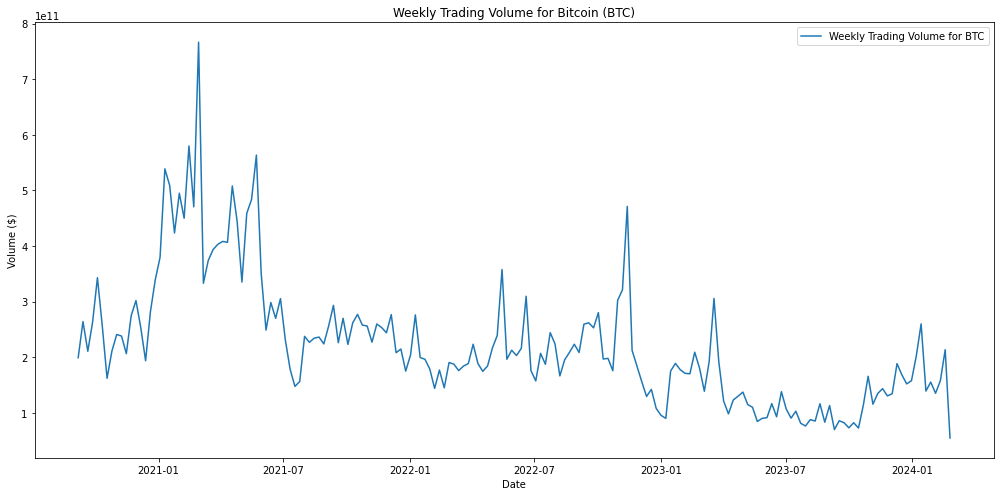

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

btc_volume = df[df['Symbol'] == 'BTC'].set_index('Date')['Volume($)']

# Resample to weekly volume
btc_weekly_volume = btc_volume.resample('W').sum()


plt.figure(figsize=(14, 7))
plt.plot(btc_weekly_volume.index, btc_weekly_volume, label='Weekly Trading Volume for BTC')
plt.title('Weekly Trading Volume for Bitcoin (BTC)')
plt.xlabel('Date')
plt.ylabel('Volume ($)')
plt.legend()
plt.tight_layout()
plt.show()


#### Outlier Detection:

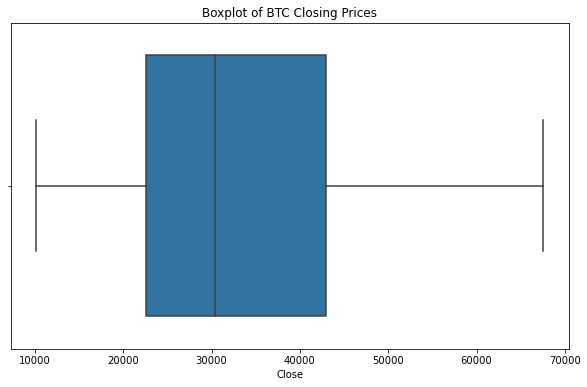

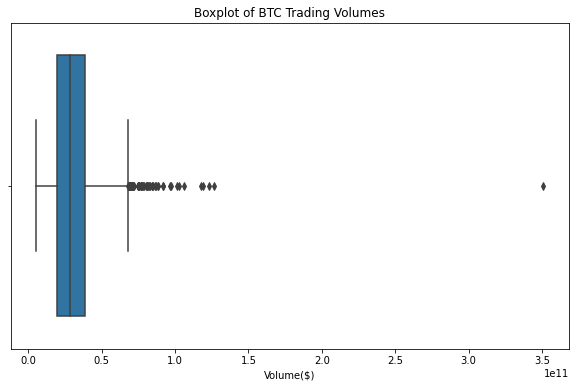

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


btc_data = df[df['Symbol'] == 'BTC']

# Boxplot for closing prices
plt.figure(figsize=(10, 6))
sns.boxplot(x=btc_data['Close'])
plt.title('Boxplot of BTC Closing Prices')
plt.show()

# Boxplot for volumes
plt.figure(figsize=(10, 6))
sns.boxplot(x=btc_data['Volume($)'])
plt.title('Boxplot of BTC Trading Volumes')
plt.show()


#### Moving Averages


##### 30-day

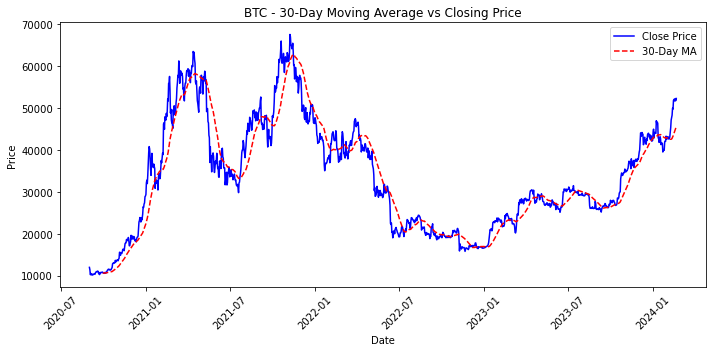

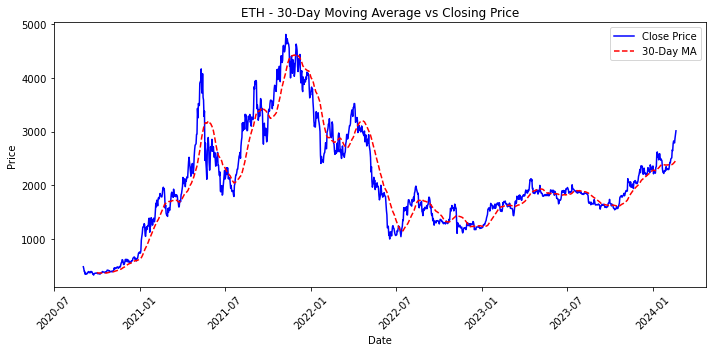

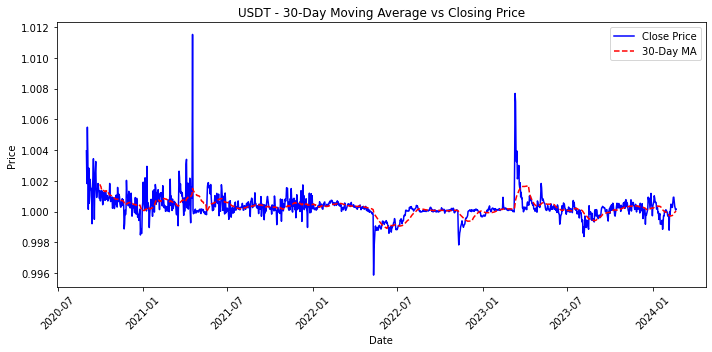

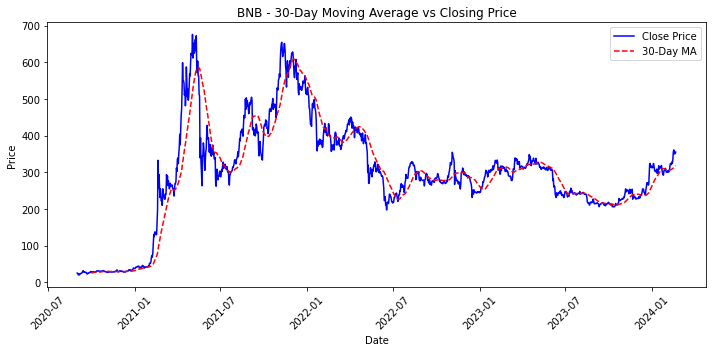

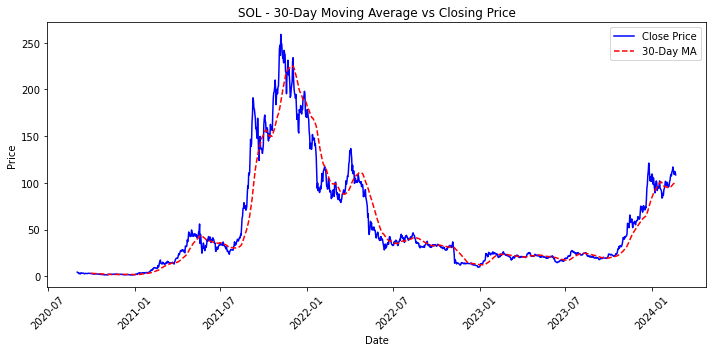

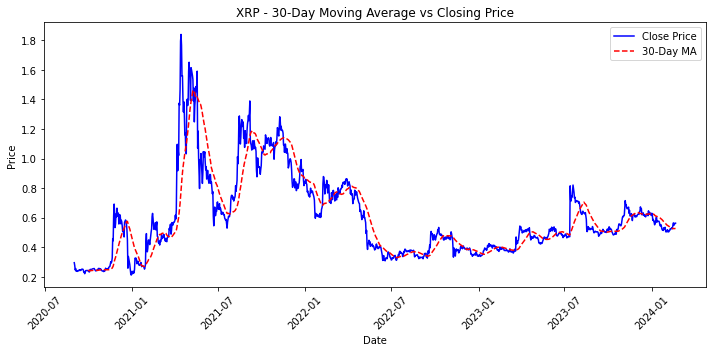

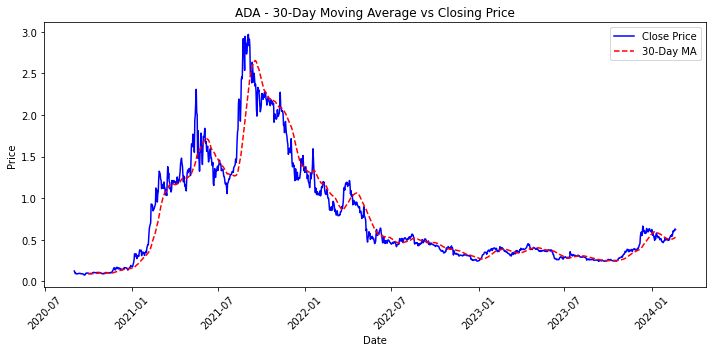

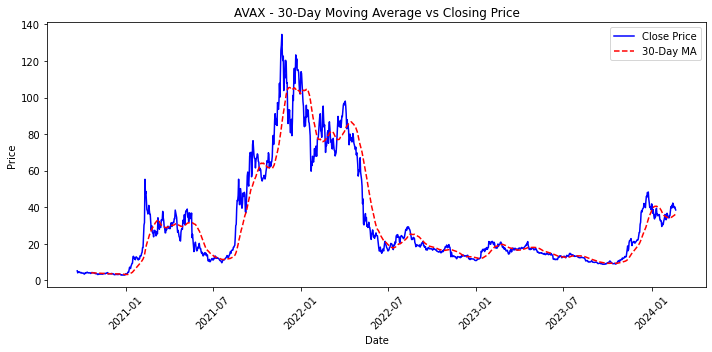

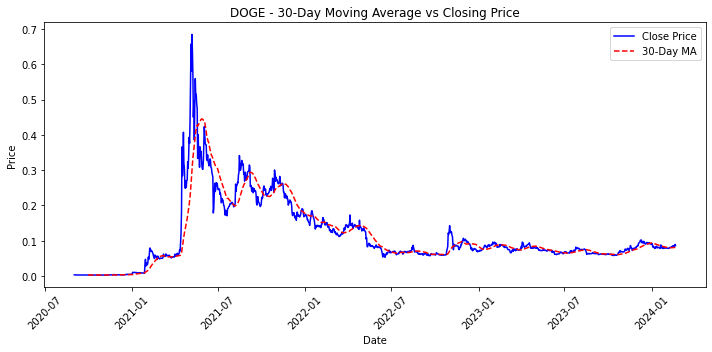

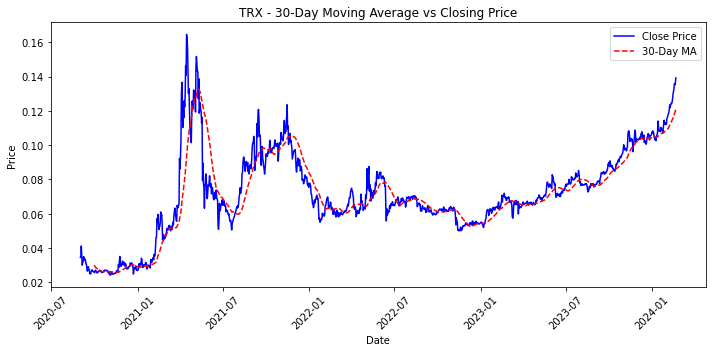

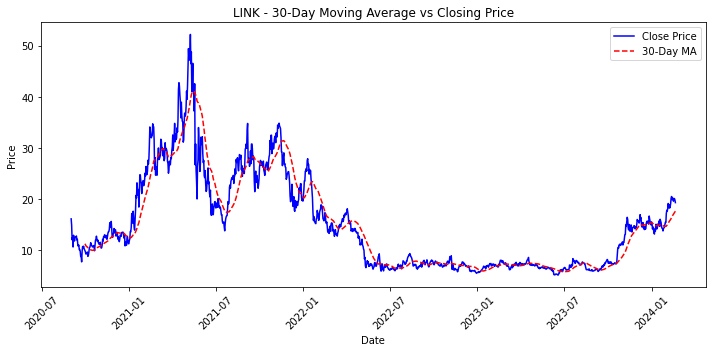

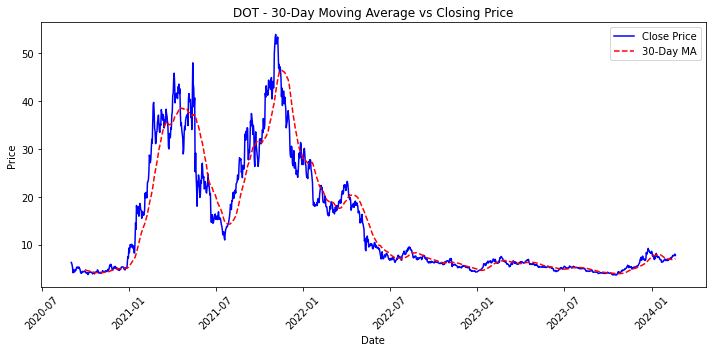

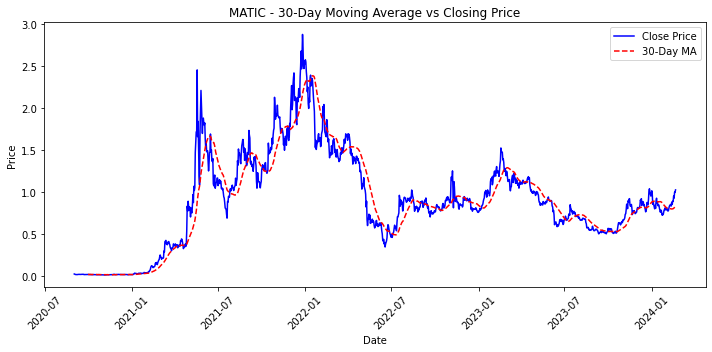

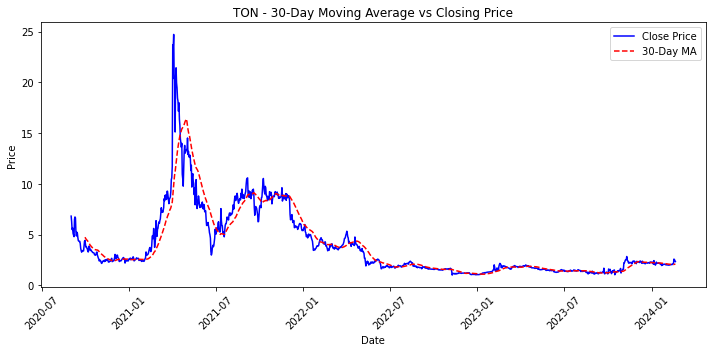

In [33]:
# Calculate 30-day Moving Averages for the Closing Prices of each stock
df['30_day_MA'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=30).mean())

stocks = df['Symbol'].unique()

# Creating a separate plot for each stock
for stock in stocks:
    subset = df[df['Symbol'] == stock]
    
    plt.figure(figsize=(10, 5))
    plt.plot(subset['Date'], subset['Close'], label='Close Price', color='blue')
    plt.plot(subset['Date'], subset['30_day_MA'], label='30-Day MA', linestyle='--', color='red')
    
    plt.title(f'{stock} - 30-Day Moving Average vs Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### 60-day

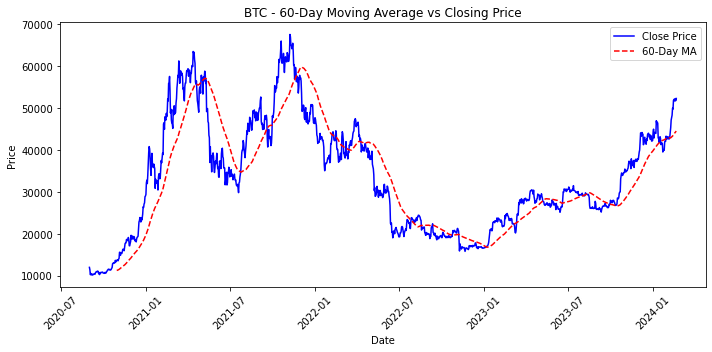

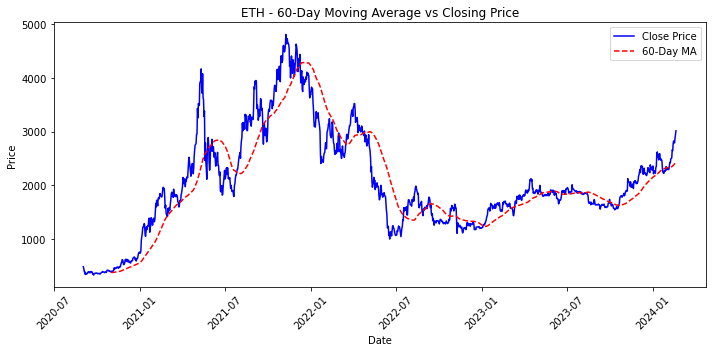

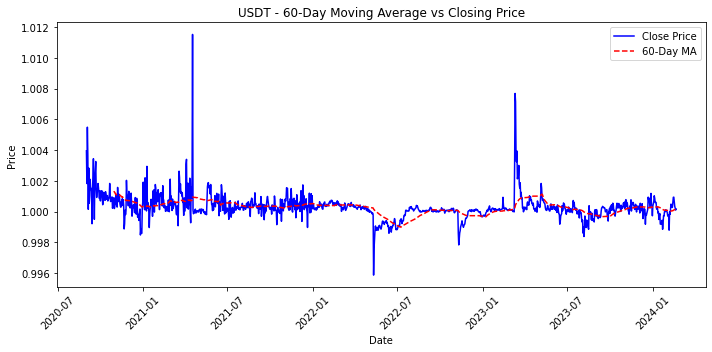

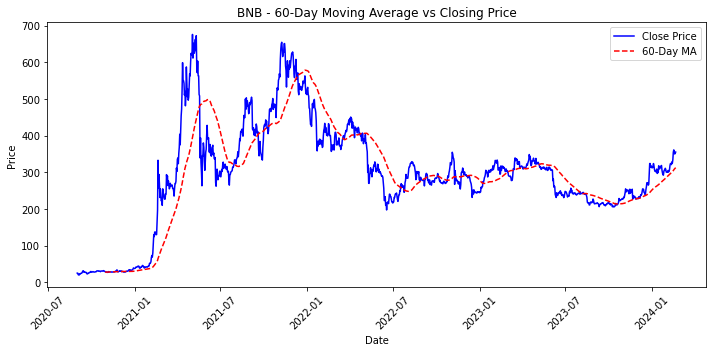

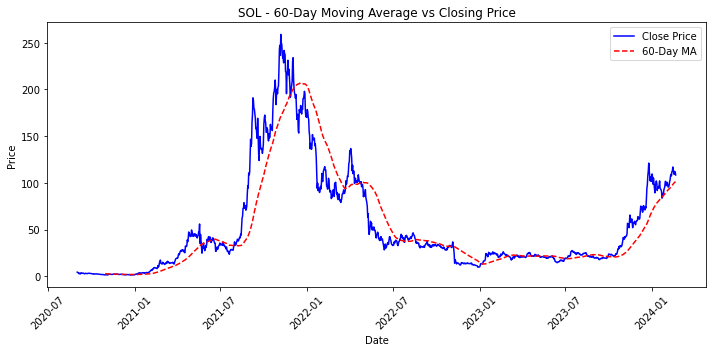

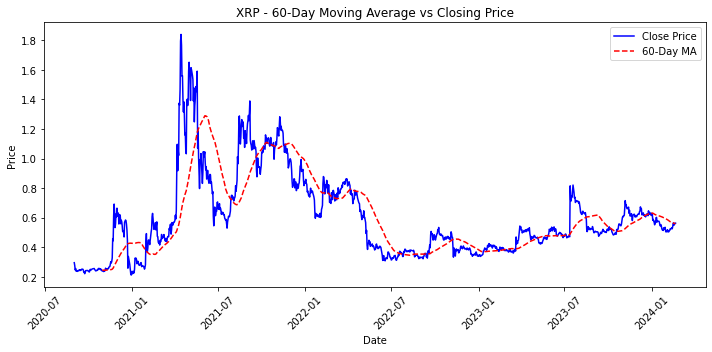

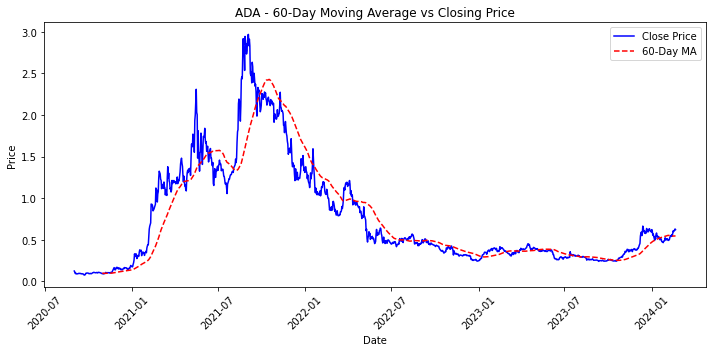

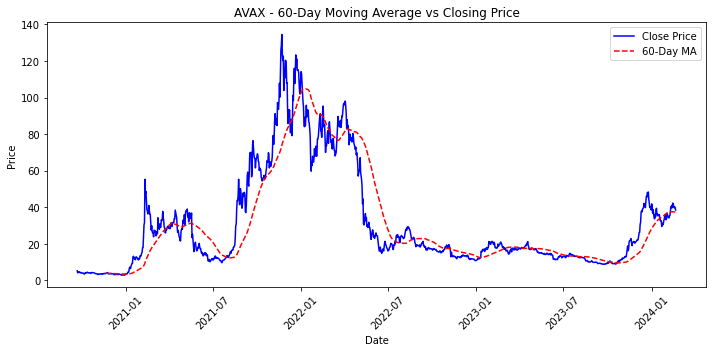

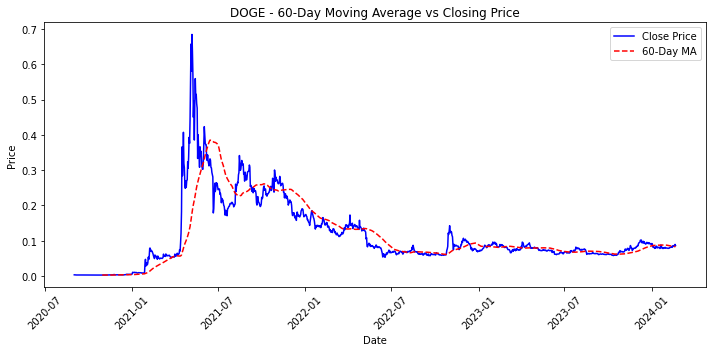

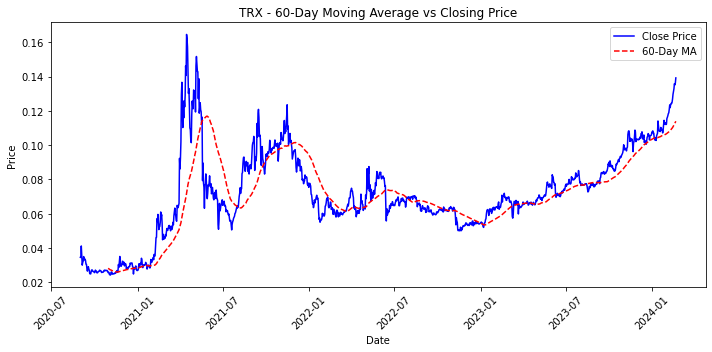

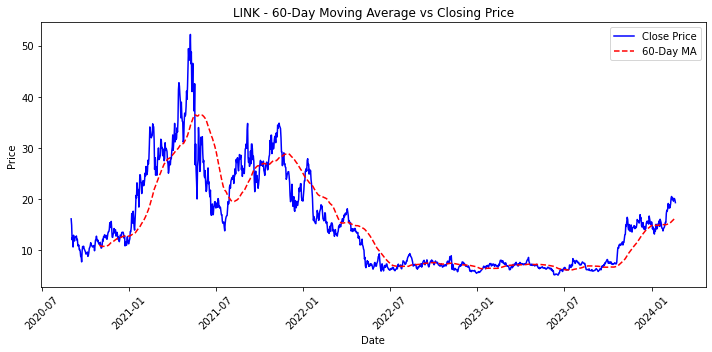

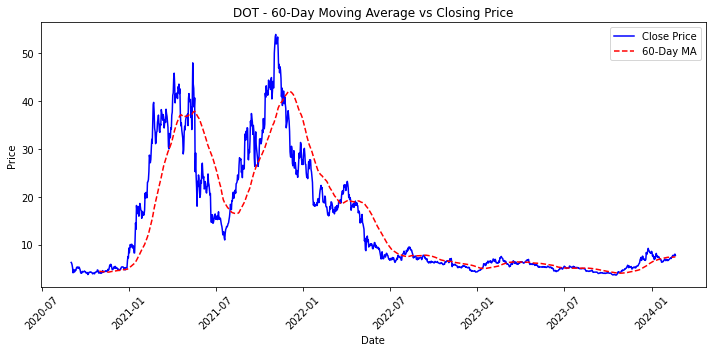

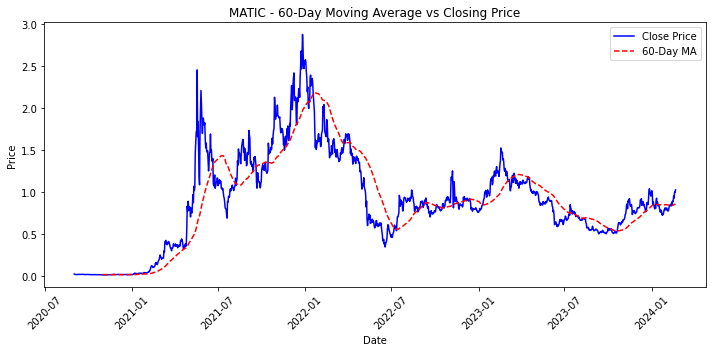

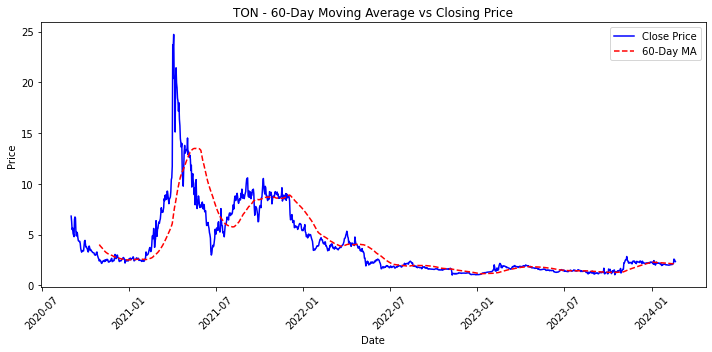

In [34]:
# Calculate 60-day Moving Averages for the Closing Prices of each stock
df['60_day_MA'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=60).mean())

stocks = df['Symbol'].unique()

# Creating a separate plot for each stock
for stock in stocks:
    subset = df[df['Symbol'] == stock]
    
    plt.figure(figsize=(10, 5))
    plt.plot(subset['Date'], subset['Close'], label='Close Price', color='blue')
    plt.plot(subset['Date'], subset['60_day_MA'], label='60-Day MA', linestyle='--', color='red')
    
    plt.title(f'{stock} - 60-Day Moving Average vs Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##### 90-day

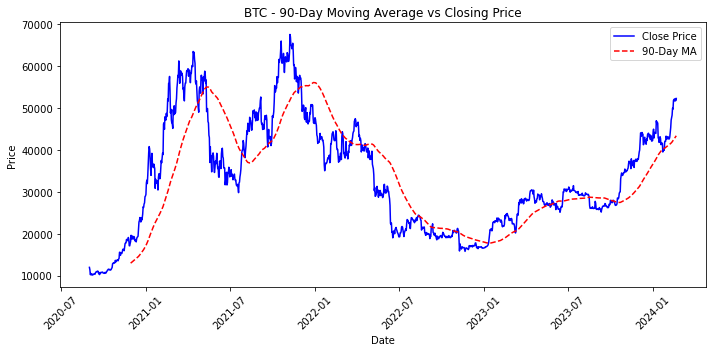

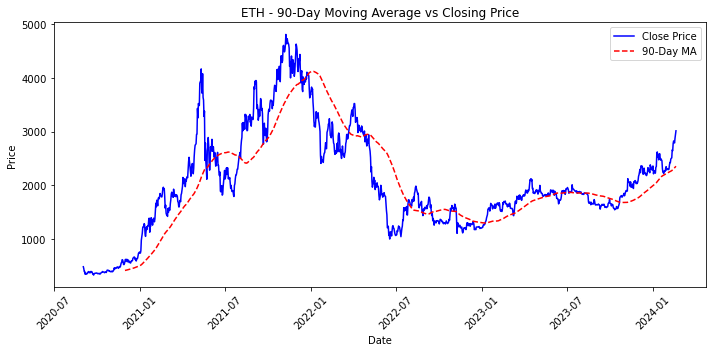

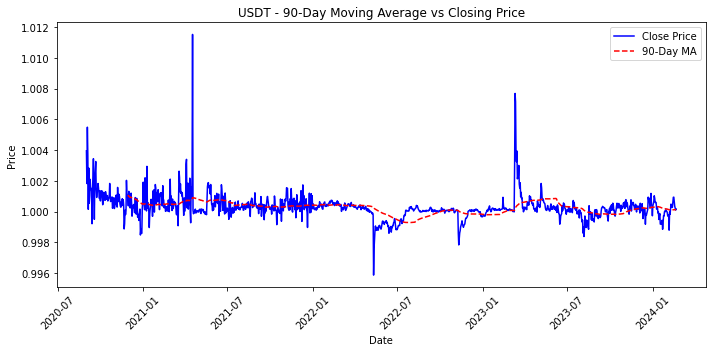

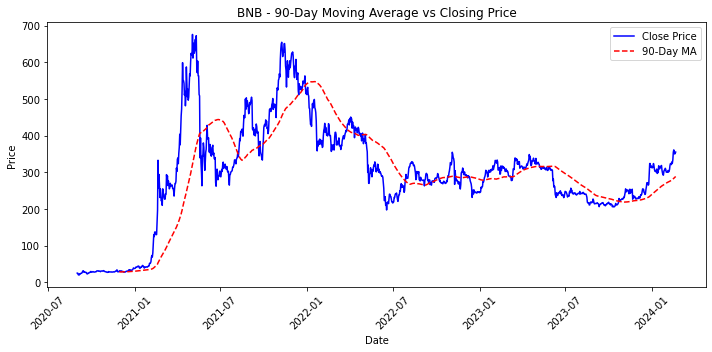

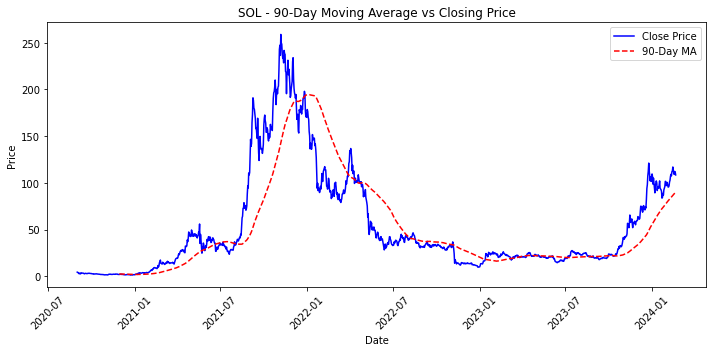

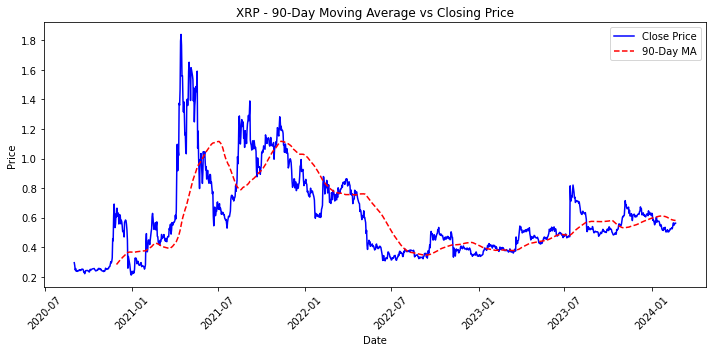

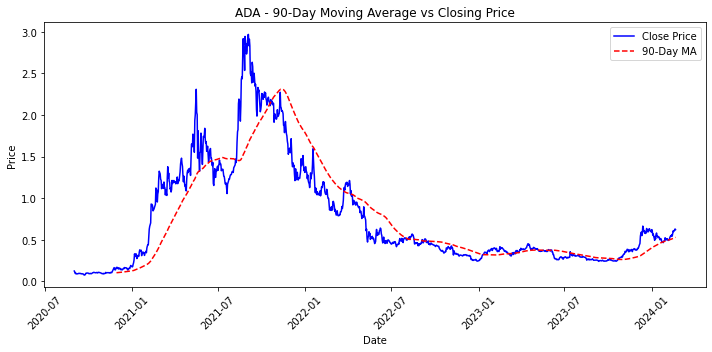

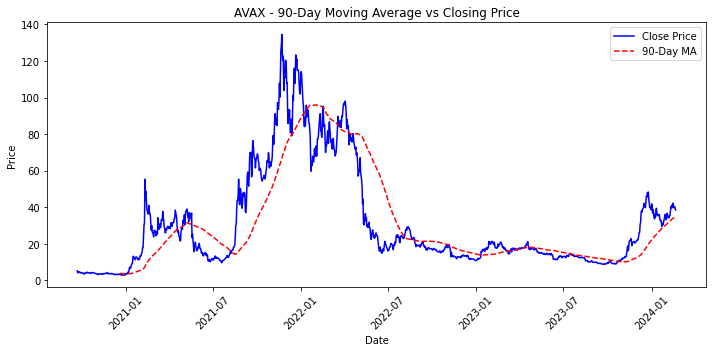

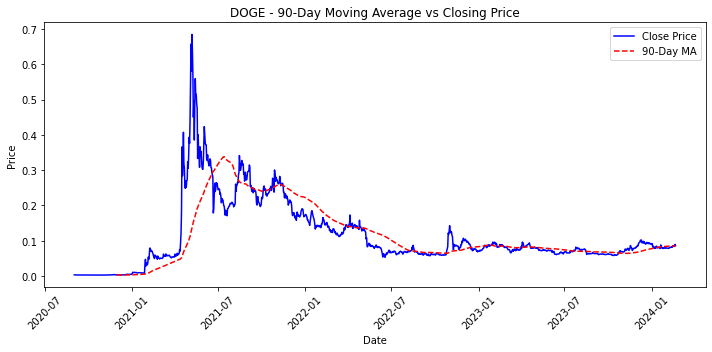

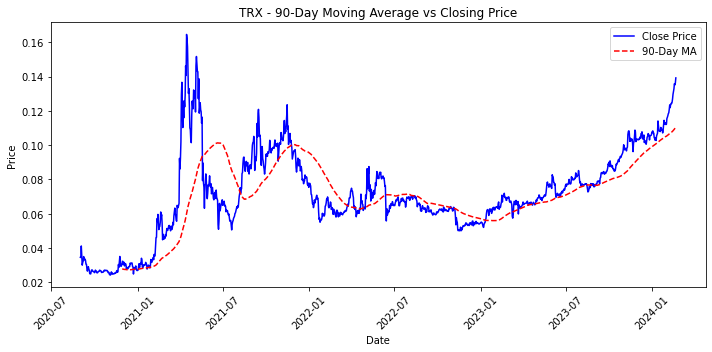

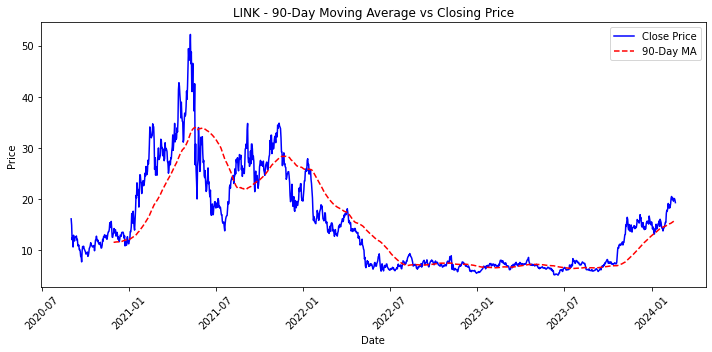

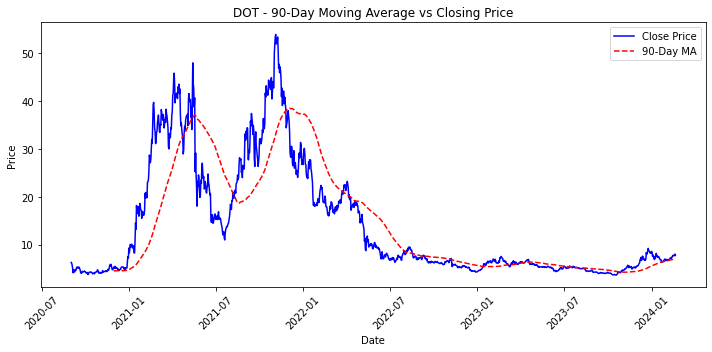

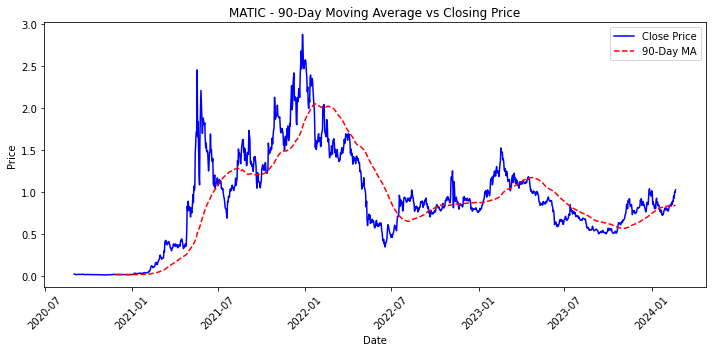

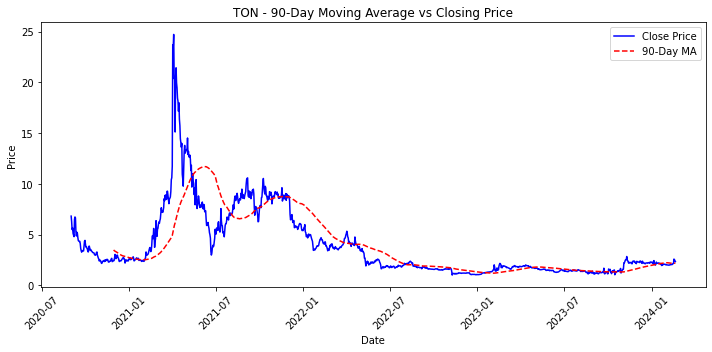

In [35]:
# Calculate 90-day Moving Averages for the Closing Prices of each stock
df['90_day_MA'] = df.groupby('Symbol')['Close'].transform(lambda x: x.rolling(window=90).mean())

stocks = df['Symbol'].unique()

# Creating a separate plot for each stock
for stock in stocks:
    subset = df[df['Symbol'] == stock]
    
    plt.figure(figsize=(10, 5))
    plt.plot(subset['Date'], subset['Close'], label='Close Price', color='blue')
    plt.plot(subset['Date'], subset['90_day_MA'], label='90-Day MA', linestyle='--', color='red')
    
    plt.title(f'{stock} - 90-Day Moving Average vs Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [36]:
df.drop(['30_day_MA', '60_day_MA', '90_day_MA'], axis=1, inplace=True)


#### Seasonality Analysis

In [37]:
df_seasonality =  df 

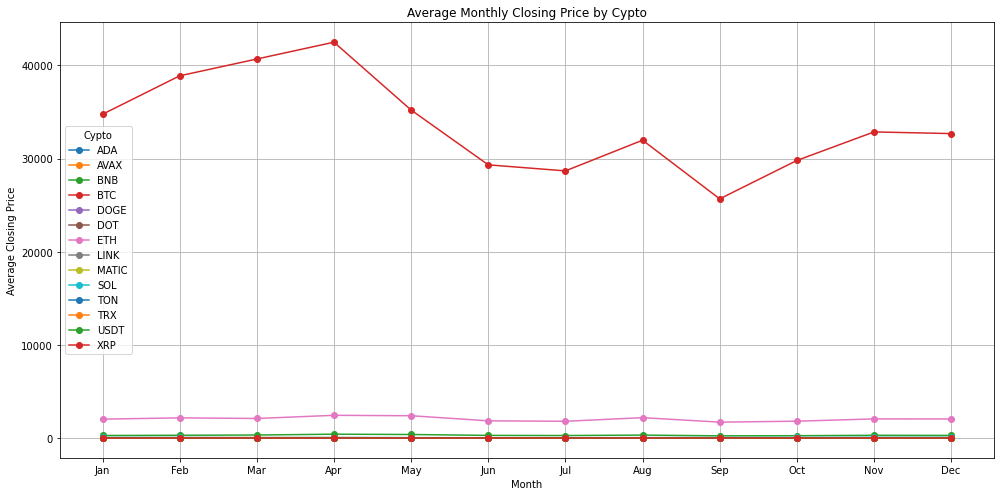

In [38]:
# Resample data to monthly and calculate average closing price for each stock
df_seasonality['Month'] = df_seasonality['Date'].dt.month
monthly_avg = df_seasonality.groupby(['Symbol', 'Month'])['Close'].mean().unstack(level=0)

# Plot the monthly average closing price for each stock
monthly_avg.plot(figsize=(14, 7), marker='o')
plt.title('Average Monthly Closing Price by Cypto')
plt.xlabel('Month')
plt.ylabel('Average Closing Price')
plt.grid(True)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Cypto')
plt.tight_layout()
plt.show()

##### Volatility- Daily Price changes 

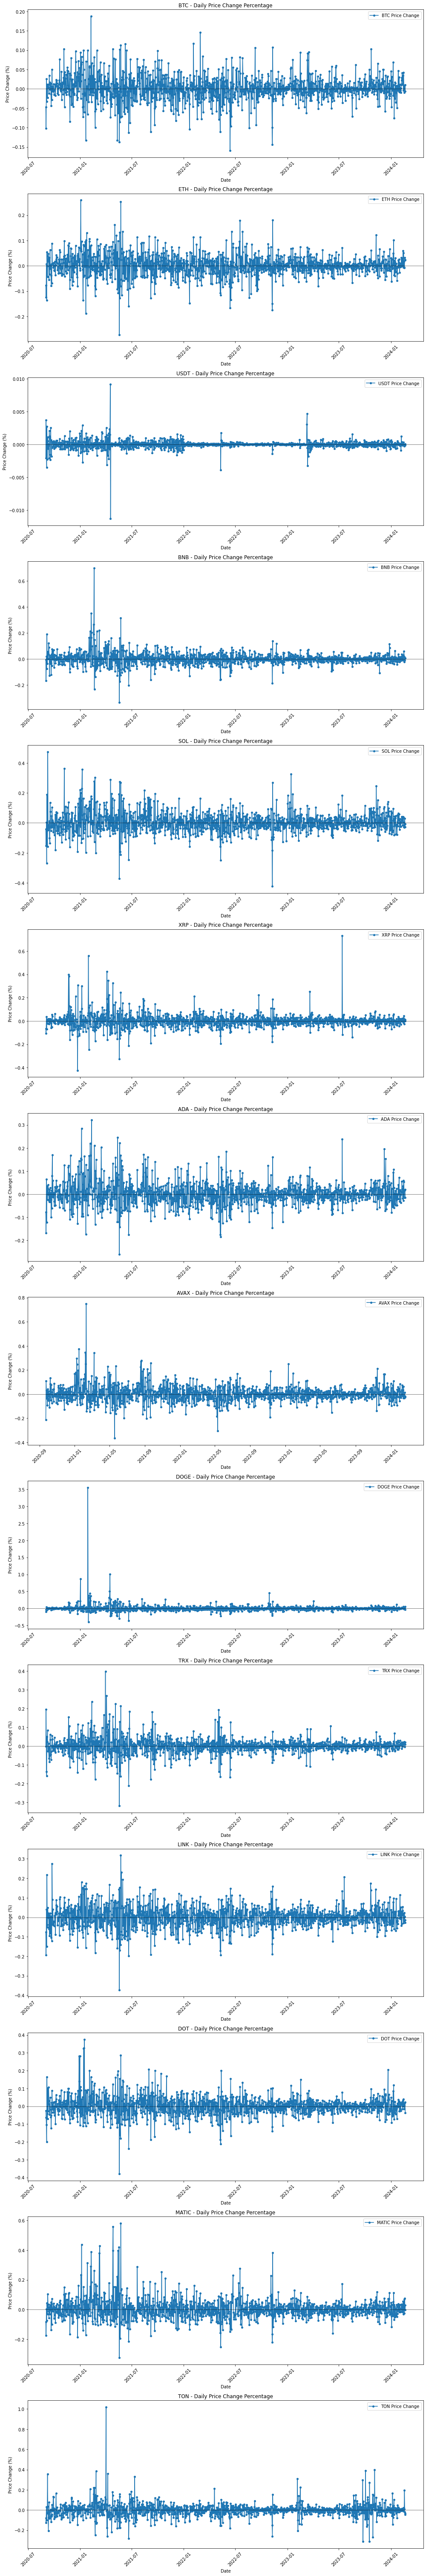

In [39]:
df_stocks_volatility = df


stocks = df_stocks_volatility['Symbol'].unique()
num_stocks = len(stocks)
fig, axes = plt.subplots(num_stocks, 1, figsize=(14, 6 * num_stocks))

for i, stock in enumerate(stocks):
    subset = df_stocks_volatility[df_stocks_volatility['Symbol'] == stock]
    axes[i].plot(subset['Date'], subset['Daily Return'], label=f'{stock} Price Change', marker='o', linestyle='-', markersize=4)
    axes[i].set_title(f'{stock} - Daily Price Change Percentage')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price Change (%)')
    axes[i].legend()
    axes[i].axhline(0, color='black', linewidth=0.5)   
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


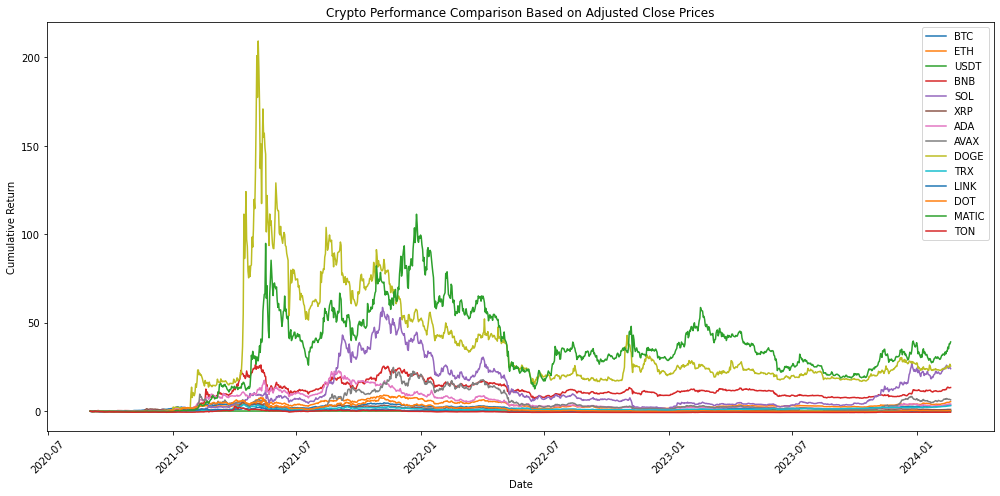

In [40]:
plt.figure(figsize=(14, 7))

# Plot the cumulative product of percentage changes to compare performance over time
for stock in df['Symbol'].unique():
    subset = df[df['Symbol'] == stock]
    # Calculate cumulative return
    cumulative_return = (1 + subset['Daily Return']).cumprod() - 1
    plt.plot(subset['Date'], cumulative_return, label=stock)

plt.title('Crypto Performance Comparison Based on Adjusted Close Prices')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Volume vs. Price Movements

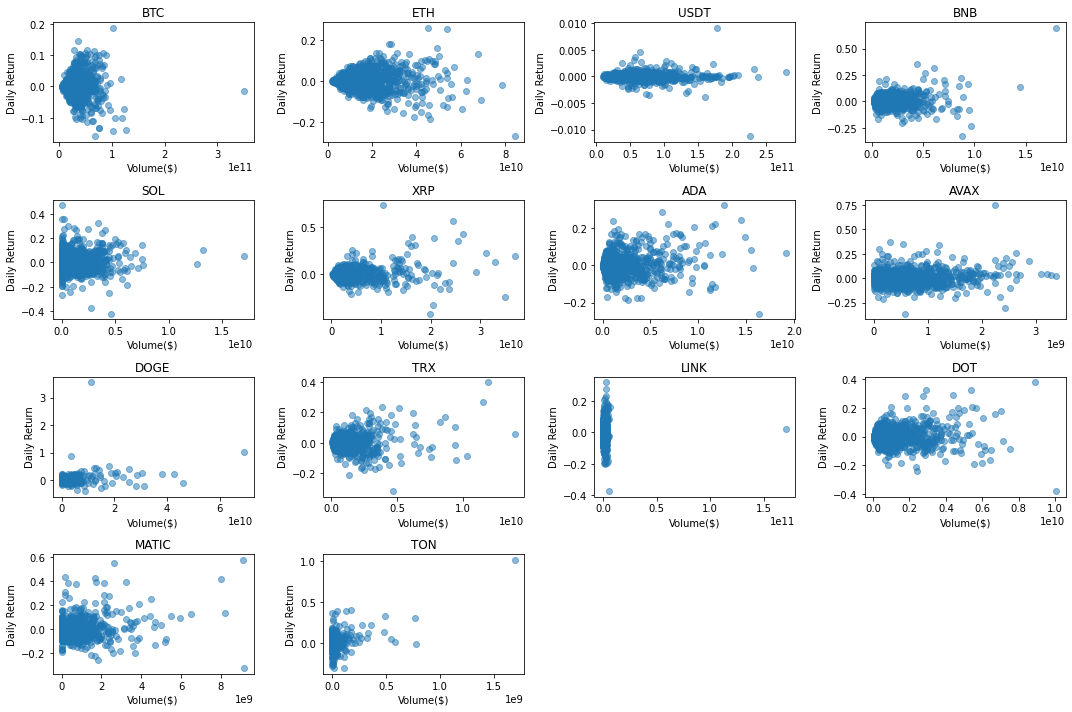

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

unique_symbols = df['Symbol'].unique()
num_symbols = len(unique_symbols)

grid_size = int(num_symbols ** 0.5) + 1

plt.figure(figsize=(15, 10))

for i, symbol in enumerate(unique_symbols, start=1):
    plt.subplot(grid_size, grid_size, i)
    subset = df[df['Symbol'] == symbol]
    plt.scatter(subset['Volume($)'], subset['Daily Return'], alpha=0.5)
    plt.title(f'{symbol}')
    plt.xlabel('Volume($)')
    plt.ylabel('Daily Return')

plt.tight_layout()
plt.show()


In [42]:
correlation_df = df.groupby('Symbol').apply(lambda x: x[['Volume($)', 'Daily Return']].corr().iloc[0, 1])

print(correlation_df)


Symbol
ADA      0.141131
AVAX     0.114240
BNB      0.164928
BTC     -0.029299
DOGE     0.260668
DOT      0.063461
ETH     -0.010221
LINK     0.019224
MATIC    0.165830
SOL      0.045065
TON      0.442709
TRX      0.126574
USDT    -0.025069
XRP      0.159473
dtype: float64


In [43]:
df['Symbol'].unique()

array(['BTC', 'ETH', 'USDT', 'BNB', 'SOL', 'XRP', 'ADA', 'AVAX', 'DOGE',
       'TRX', 'LINK', 'DOT', 'MATIC', 'TON'], dtype=object)